Approximate Stability Boundary Limit h < 1.0


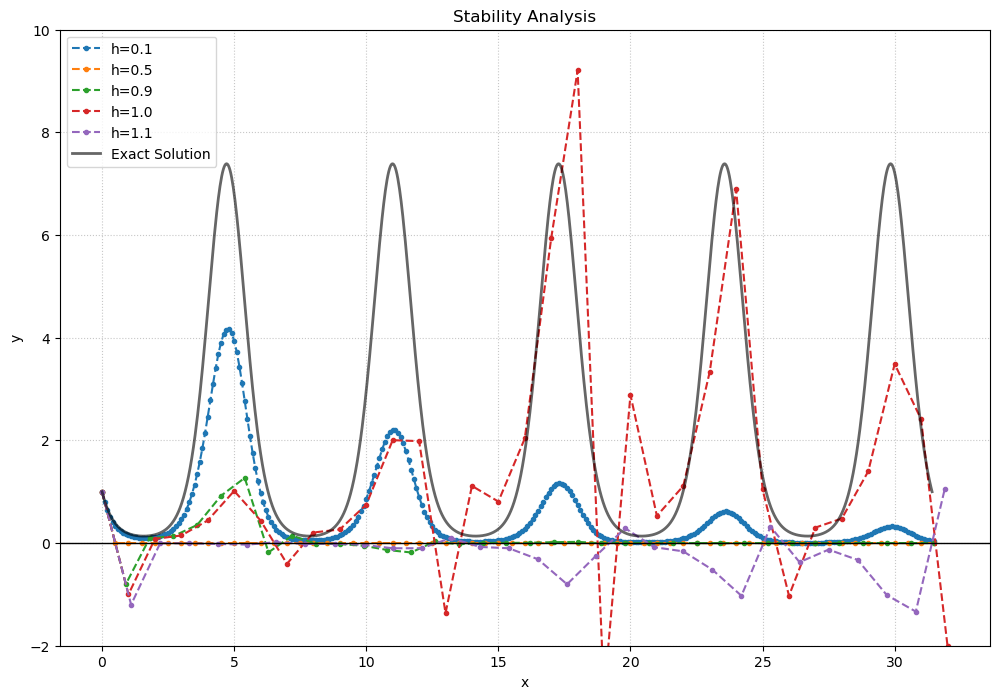

In [11]:
import numpy as np
import matplotlib.pyplot as plt

#function we want to solve
def f(x, y):
    return -2 * y * np.cos(x)

#function that retrieves the lambdas for stability condition
#in this case, the lambda (eigenvalues) is a function because of the two variables in the equation.
def get_lambda(x):
    return -2 * np.cos(x)

#function that returns the exact solution at a certain point
def exact_sol(x, y0):
    return y0 * np.exp(-2 * np.sin(x))

#initalize parameters
xi, xf = 0, 10 * np.pi
y0 = 1

#h values for testing around stability
steps = [0.1, 0.5, 0.9, 1.0, 1.1] 

#stability requires |1 + h*lambda| < 1. This block of code calculates the required h to stay within the stability condition
x_h = np.linspace(xi, xf, 1000)
minLambda = np.min(get_lambda(x_h))
critical_h = 2 / abs(minLambda)
#this is the boundary condition
print(f"Approximate Stability Boundary Limit h < {critical_h}")

plt.figure(figsize=(12, 8))

#euler's method of solving the differential equation
for h in steps:
    num_steps = int((xf - xi) / h)
    x = np.arange(xi, xf + h, h)
    y = np.zeros(len(x))
    y[0] = y0
    
    for i in range(len(x) - 1):
        y[i+1] = y[i] + h * f(x[i], y[i])
    plt.plot(x, y, '--o', markersize=3, label=f'h={h}')

#exact solution plotting
x_plot = np.linspace(xi, xf, 1000)
plt.plot(x_plot, exact_sol(x_plot, 1), 'k', lw=2, label='Exact Solution', alpha=0.6)


#plotting the stability analysis of different step sizes
plt.title("Stability Analysis")
plt.xlabel("x")
plt.ylabel("y")
plt.ylim(-2, 10) 
plt.axhline(0, color='black', lw=1)
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend()
plt.show()

# This boundary condition does affect the choice of h, as this boundary condition is the maximum allowed value of h that you can set the method to. In this case, if h > 1, then tjhe term |1 + h*lambda| will exceed 1 at places where cos(x) = 1, resulting in errors that diverge too wildly to be controlled.

# I used gemini pro to help me think through the problem and determine the stability conditions, as well as make the graph more readable.